In [25]:
import numpy as np
import matplotlib.pyplot as plt
import time

import jax
import jax.numpy as jnp

import importlib, os
import east
importlib.reload(east)

plt.rcParams['figure.dpi'] = 120


## Walker-count pooled DMD comparison

Repeat the same pooled single-site DMD smoke test for multiple independent isoconfigurational walker counts.


In [26]:
key = jax.random.PRNGKey(11)

# Use the same high-temperature case from DMD.ipynb so this remains a quick smoke test.
l_test = 3
T = float(east.temperature_from_length(l_test))
c_eq = float(east.concentration(T))

# Keep the original simulation settings fixed while varying only walkers/config.
N = 256
n_configs = 16
walker_counts = [128, 512, 1024, 2048]
n_records = 500

# Reuse the ACF-derived window when present; otherwise use a conservative fast fallback.
tau_acf_ref = None
if os.path.exists('acf_results.npy'):
    acf_results = np.load('acf_results.npy', allow_pickle=True).item()
    if l_test in acf_results:
        tau_acf_ref = float(acf_results[l_test]['tau'])
        dt_record = tau_acf_ref / 250
    else:
        dt_record = 0.25
else:
    dt_record = 0.25

times = np.arange(n_records + 1) * dt_record
T_window = times[-1]
mu_micro = -np.exp(-1.0 / T)

print(f'l={l_test}, T={T:.4f}, c_eq={c_eq:.4f}')
print(f'N={N}, configs={n_configs}, walker_counts={walker_counts}')
if tau_acf_ref is None:
    print(f'dt={dt_record:.4g}, max_t={times[-1]:.2f}')
else:
    print(f'dt={dt_record:.4g}, max_t={times[-1]:.2f} ({times[-1] / tau_acf_ref:.2f} tau_acf)')
print(f'microscopic excitation-rate guide: Re(mu) = -exp(-1/T) = {mu_micro:.5g}')


l=3, T=1.4427, c_eq=0.3333
N=256, configs=16, walker_counts=[128, 512, 1024, 2048]
dt=0.04279, max_t=21.40 (2.00 tau_acf)
microscopic excitation-rate guide: Re(mu) = -exp(-1/T) = -0.5


In [27]:
def sample_fixed_concentration_config(key, N, c_eq):
    """Equilibrium-like initial state with exactly round(N c_eq) excitations."""
    n_up = int(round(N * c_eq))
    return jax.random.permutation(
        key,
        jnp.concatenate([
            jnp.ones(n_up, dtype=jnp.int32),
            jnp.zeros(N - n_up, dtype=jnp.int32),
        ])
    )


def generate_mean_trajectories(key, n_walkers):
    """Generate independent isoconfigurational averages for one walker count."""
    mean_trajs = []
    state_inits = []

    t0 = time.time()
    for config_idx in range(n_configs):
        key, init_key, run_key = jax.random.split(key, 3)
        state_init = sample_fixed_concentration_config(init_key, N, c_eq)
        mean_traj, walker_trajs = east.isoconfigurational_ensemble(
            N, T, dt_record, n_records, n_walkers, state_init, run_key
        )
        mean_trajs.append(np.asarray(mean_traj))
        state_inits.append(np.asarray(state_init))
        del walker_trajs
        print(
            f'walkers={n_walkers:4d}, config {config_idx + 1:2d}/{n_configs}: '
            f'mean_traj {tuple(mean_traj.shape)}'
        )

    mean_trajs = np.stack(mean_trajs, axis=0)      # (n_configs, time, N)
    state_inits = np.stack(state_inits, axis=0)    # (n_configs, N)
    print(f'walkers={n_walkers:4d}: generated mean_trajs {mean_trajs.shape} in {time.time() - t0:.1f}s')
    return key, mean_trajs, state_inits


results = {}
for n_walkers in walker_counts:
    print(f'\n=== n_walkers = {n_walkers} ===')
    key, mean_trajs, state_inits = generate_mean_trajectories(key, n_walkers)
    results[n_walkers] = {
        'mean_trajs': mean_trajs,
        'state_inits': state_inits,
    }



=== n_walkers = 128 ===
walkers= 128, config  1/16: mean_traj (501, 256)
walkers= 128, config  2/16: mean_traj (501, 256)
walkers= 128, config  3/16: mean_traj (501, 256)
walkers= 128, config  4/16: mean_traj (501, 256)
walkers= 128, config  5/16: mean_traj (501, 256)
walkers= 128, config  6/16: mean_traj (501, 256)
walkers= 128, config  7/16: mean_traj (501, 256)
walkers= 128, config  8/16: mean_traj (501, 256)
walkers= 128, config  9/16: mean_traj (501, 256)
walkers= 128, config 10/16: mean_traj (501, 256)
walkers= 128, config 11/16: mean_traj (501, 256)
walkers= 128, config 12/16: mean_traj (501, 256)
walkers= 128, config 13/16: mean_traj (501, 256)
walkers= 128, config 14/16: mean_traj (501, 256)
walkers= 128, config 15/16: mean_traj (501, 256)
walkers= 128, config 16/16: mean_traj (501, 256)
walkers= 128: generated mean_trajs (16, 501, 256) in 25.8s

=== n_walkers = 512 ===
walkers= 512, config  1/16: mean_traj (501, 256)
walkers= 512, config  2/16: mean_traj (501, 256)
walkers= 

## Single-site dictionary


In [28]:
def single_site_dictionary(mean_spins, c_eq):
    """Return standardized [1, s_i] features from walker-averaged spins."""
    mean_spins = np.asarray(mean_spins, dtype=np.float64)
    sigma = np.sqrt(c_eq * (1.0 - c_eq))
    spin_features = (mean_spins - c_eq) / sigma
    const = np.ones((mean_spins.shape[0], 1), dtype=np.float64)
    return np.hstack([const, spin_features])


def build_single_site_dmd_matrices(mean_trajs):
    Psis = np.stack([
        single_site_dictionary(mean_trajs[j], c_eq)
        for j in range(n_configs)
    ], axis=0)                                      # (n_configs, time, D)

    X = np.concatenate([Psis[j, :-1].T for j in range(n_configs)], axis=1)
    Y = np.concatenate([Psis[j, 1:].T for j in range(n_configs)], axis=1)
    return Psis, X, Y


for n_walkers, res in results.items():
    Psis, X, Y = build_single_site_dmd_matrices(res['mean_trajs'])
    D, M = X.shape
    res.update({'Psis': Psis, 'X': X, 'Y': Y})
    print(f'walkers={n_walkers:4d}: Psis={Psis.shape}, D={D}, pooled snapshot pairs={M}')


walkers= 128: Psis=(16, 501, 257), D=257, pooled snapshot pairs=8000
walkers= 512: Psis=(16, 501, 257), D=257, pooled snapshot pairs=8000
walkers=1024: Psis=(16, 501, 257), D=257, pooled snapshot pairs=8000
walkers=2048: Psis=(16, 501, 257), D=257, pooled snapshot pairs=8000


Text(0.5, 0.98, 'Standardized DMD observables, config 1')

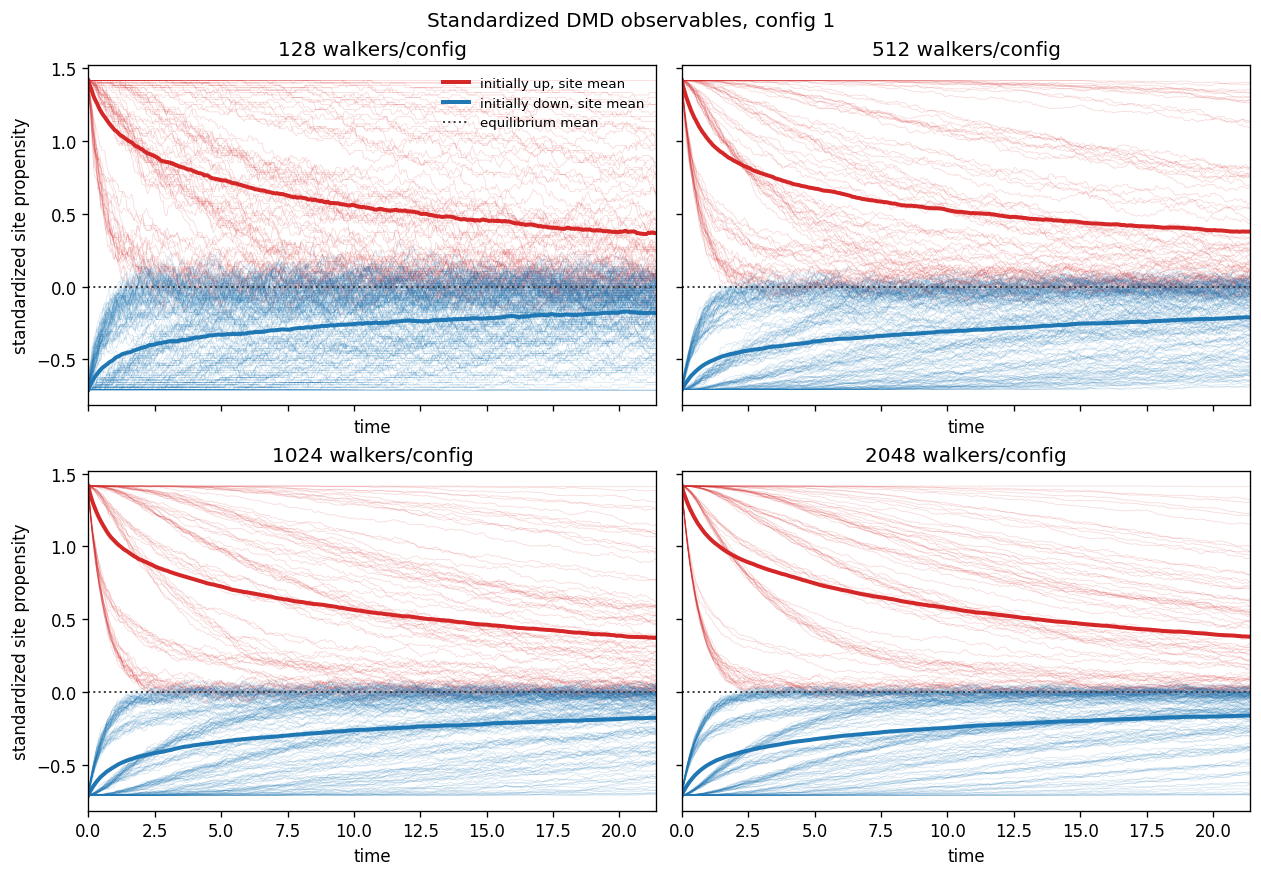

In [29]:
plot_config = 0
fig, axes_grid = plt.subplots(2, 2, figsize=(10.4, 7.2), sharex=True, sharey=True, constrained_layout=True)
axes = axes_grid.ravel()
for ax in axes[len(walker_counts):]:
    ax.set_visible(False)

for ax, n_walkers in zip(axes, walker_counts):
    res = results[n_walkers]
    Psi_plot = res['Psis'][plot_config]
    state_plot = res['state_inits'][plot_config]
    up_mask = state_plot == 1
    dn_mask = state_plot == 0

    # Skip the constant observable at column 0; plot standardized single-site observables.
    for idx in np.where(up_mask)[0]:
        ax.plot(times, Psi_plot[:, idx + 1], color='tab:red', lw=0.45, alpha=0.18)
    for idx in np.where(dn_mask)[0]:
        ax.plot(times, Psi_plot[:, idx + 1], color='tab:blue', lw=0.45, alpha=0.18)

    ax.plot(times, Psi_plot[:, 1:][:, up_mask].mean(axis=1), color='tab:red', lw=2.4,
            label='initially up, site mean')
    ax.plot(times, Psi_plot[:, 1:][:, dn_mask].mean(axis=1), color='tab:blue', lw=2.4,
            label='initially down, site mean')
    ax.axhline(0.0, color='0.25', ls=':', lw=1.2, label='equilibrium mean')

    ax.set_title(f'{n_walkers} walkers/config')
    ax.set_xlabel('time')
    ax.margins(x=0)

axes[0].set_ylabel('standardized site propensity')
axes[2].set_ylabel('standardized site propensity')
axes[0].legend(frameon=False, loc='best', fontsize=8)
fig.suptitle(f'Standardized DMD observables, config {plot_config + 1}')


In [30]:
def fit_exact_dmd(X, Y, dt, energy=0.999, r_max=None):
    """Exact DMD with energy-based SVD truncation."""
    U, s, Vh = np.linalg.svd(X, full_matrices=False)
    cumulative = np.cumsum(s**2) / np.sum(s**2)
    r = int(np.searchsorted(cumulative, energy) + 1)
    if r_max is not None:
        r = min(r, int(r_max))

    Ur = U[:, :r]
    sr = s[:r]
    Vr = Vh.conj().T[:, :r]

    A_tilde = Ur.conj().T @ Y @ Vr @ np.diag(1.0 / sr)
    lam, W = np.linalg.eig(A_tilde)
    Phi = Y @ Vr @ np.diag(1.0 / sr) @ W
    mu = np.log(lam.astype(complex)) / dt

    return {
        'U': Ur,
        's': sr,
        'rank': r,
        'lambda': lam,
        'mu': mu,
        'Phi': Phi,
        'A_tilde': A_tilde,
    }


def mode_diagnostics(fit, Psis, times):
    """Amplitude and window-integrated contribution diagnostics per DMD mode."""
    Phi = fit['Phi']
    mu = fit['mu']

    amplitudes = np.stack([
        np.linalg.lstsq(Phi, Psis[j, 0], rcond=None)[0]
        for j in range(Psis.shape[0])
    ], axis=0)  # (n_configs, rank)

    # Ignore the constant observable when estimating whether a decaying mode matters.
    mode_shape_norm = np.linalg.norm(Phi[1:, :], axis=0)
    temporal_norm = np.sqrt(np.sum(np.abs(np.exp(np.outer(mu, times))) ** 2, axis=1))
    integrated_effect = np.abs(amplitudes) * mode_shape_norm[None, :] * temporal_norm[None, :]

    mean_abs_b = np.mean(np.abs(amplitudes), axis=0)
    mean_effect = np.mean(integrated_effect, axis=0)
    effect_fraction = mean_effect / np.sum(mean_effect) if np.sum(mean_effect) > 0 else mean_effect

    tau = np.full(mu.shape, np.inf, dtype=float)
    decaying = np.real(mu) < -1e-12
    tau[decaying] = 1.0 / np.abs(np.real(mu[decaying]))

    return {
        'amplitudes': amplitudes,
        'mean_abs_b': mean_abs_b,
        'mean_effect': mean_effect,
        'effect_fraction': effect_fraction,
        'tau': tau,
    }


for n_walkers, res in results.items():
    fit = fit_exact_dmd(res['X'], res['Y'], dt_record, energy=0.999, r_max=80)
    mode_diag = mode_diagnostics(fit, res['Psis'], times)
    res.update({'fit': fit, 'mode_diag': mode_diag})
    print(f'walkers={n_walkers:4d}: rank={fit["rank"]}, T_window={T_window:.6g}')


walkers= 128: rank=80, T_window=21.3953
walkers= 512: rank=80, T_window=21.3953
walkers=1024: rank=60, T_window=21.3953
walkers=2048: rank=53, T_window=21.3953


The mode-contribution plot from `DMD.ipynb` is intentionally omitted in this walker-count comparison.


In [31]:
def reconstruct_dmd(fit, psi0, times):
    """Reconstruct feature trajectory from one initial dictionary vector."""
    Phi = fit['Phi']
    mu = fit['mu']
    b = np.linalg.lstsq(Phi, psi0, rcond=None)[0]
    dynamics = np.exp(np.outer(mu, times)) * b[:, None]
    return (Phi @ dynamics).T


sigma = np.sqrt(c_eq * (1.0 - c_eq))
for n_walkers, res in results.items():
    fit = res['fit']
    Psis = res['Psis']
    mean_trajs = res['mean_trajs']

    Psi_hats = np.stack([
        reconstruct_dmd(fit, Psis[j, 0], times)
        for j in range(n_configs)
    ], axis=0)

    mean_hats = np.real(Psi_hats[:, :, 1:] * sigma + c_eq)
    rel_errs = np.linalg.norm(mean_hats - mean_trajs, axis=(1, 2)) / np.linalg.norm(mean_trajs - c_eq, axis=(1, 2))

    res.update({'Psi_hats': Psi_hats, 'mean_hats': mean_hats, 'rel_errs': rel_errs})

    print(f'walkers={n_walkers:4d}: relative reconstruction error, mean +/- sd: {rel_errs.mean():.3e} +/- {rel_errs.std():.3e}')


walkers= 128: relative reconstruction error, mean +/- sd: 9.704e-02 +/- 2.251e-03
walkers= 512: relative reconstruction error, mean +/- sd: 4.678e-02 +/- 1.120e-03
walkers=1024: relative reconstruction error, mean +/- sd: 3.727e-02 +/- 1.475e-03
walkers=2048: relative reconstruction error, mean +/- sd: 3.659e-02 +/- 2.335e-03


Text(0.5, 0.98, 'Pooled-DMD reconstruction, config 1')

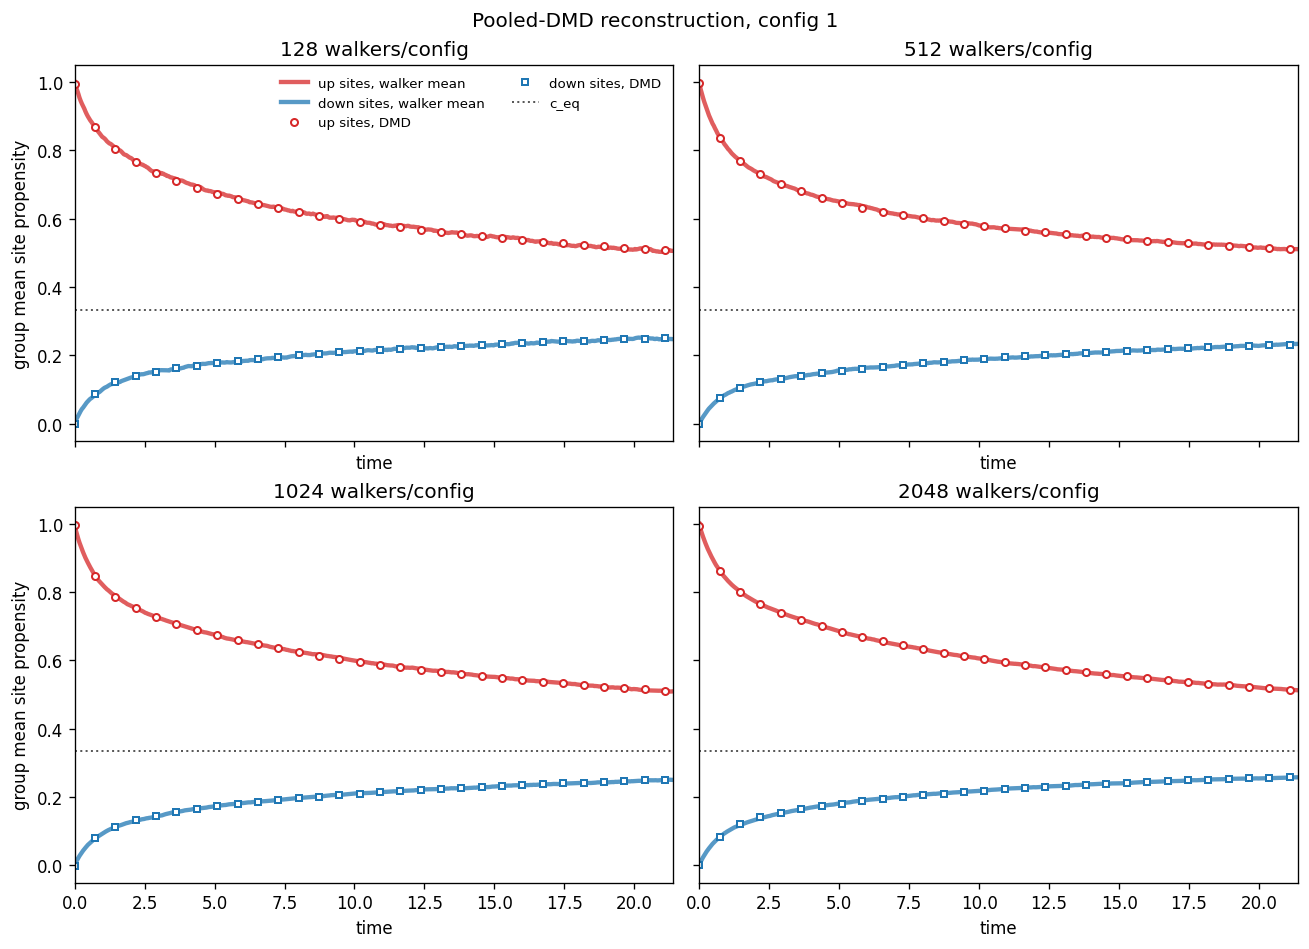

In [32]:
plot_config = 0
marker_stride = max(1, len(times) // 28)
fig, axes_grid = plt.subplots(2, 2, figsize=(10.8, 7.8), sharex=True, sharey=True, constrained_layout=True)
axes = axes_grid.ravel()
for ax in axes[len(walker_counts):]:
    ax.set_visible(False)

for ax, n_walkers in zip(axes, walker_counts):
    res = results[n_walkers]
    state_plot = res['state_inits'][plot_config]
    up_mask = state_plot == 1
    dn_mask = state_plot == 0

    mean_traj_plot = res['mean_trajs'][plot_config]
    mean_hat_plot = res['mean_hats'][plot_config]

    mean_up = mean_traj_plot[:, up_mask].mean(axis=1)
    mean_dn = mean_traj_plot[:, dn_mask].mean(axis=1)
    mean_up_hat = mean_hat_plot[:, up_mask].mean(axis=1)
    mean_dn_hat = mean_hat_plot[:, dn_mask].mean(axis=1)

    ax.plot(times, mean_up, color='tab:red', lw=2.6, alpha=0.75,
            label='up sites, walker mean')
    ax.plot(times, mean_dn, color='tab:blue', lw=2.6, alpha=0.75,
            label='down sites, walker mean')
    ax.plot(times, mean_up_hat, color='tab:red', marker='o', ls='None', ms=4.2,
            mfc='white', mec='tab:red', mew=1.2, markevery=marker_stride,
            label='up sites, DMD')
    ax.plot(times, mean_dn_hat, color='tab:blue', marker='s', ls='None', ms=4.0,
            mfc='white', mec='tab:blue', mew=1.2, markevery=marker_stride,
            label='down sites, DMD')
    ax.axhline(c_eq, color='0.35', ls=':', lw=1.2, label='c_eq')

    ax.set_title(f'{n_walkers} walkers/config')
    ax.set_xlabel('time')
    ax.margins(x=0)

axes[0].set_ylabel('group mean site propensity')
axes[2].set_ylabel('group mean site propensity')
axes[0].legend(frameon=False, ncol=2, fontsize=8)
fig.suptitle(f'Pooled-DMD reconstruction, config {plot_config + 1}')


Text(0.5, 0.98, 'Per-site pooled-DMD reconstruction, config 1')

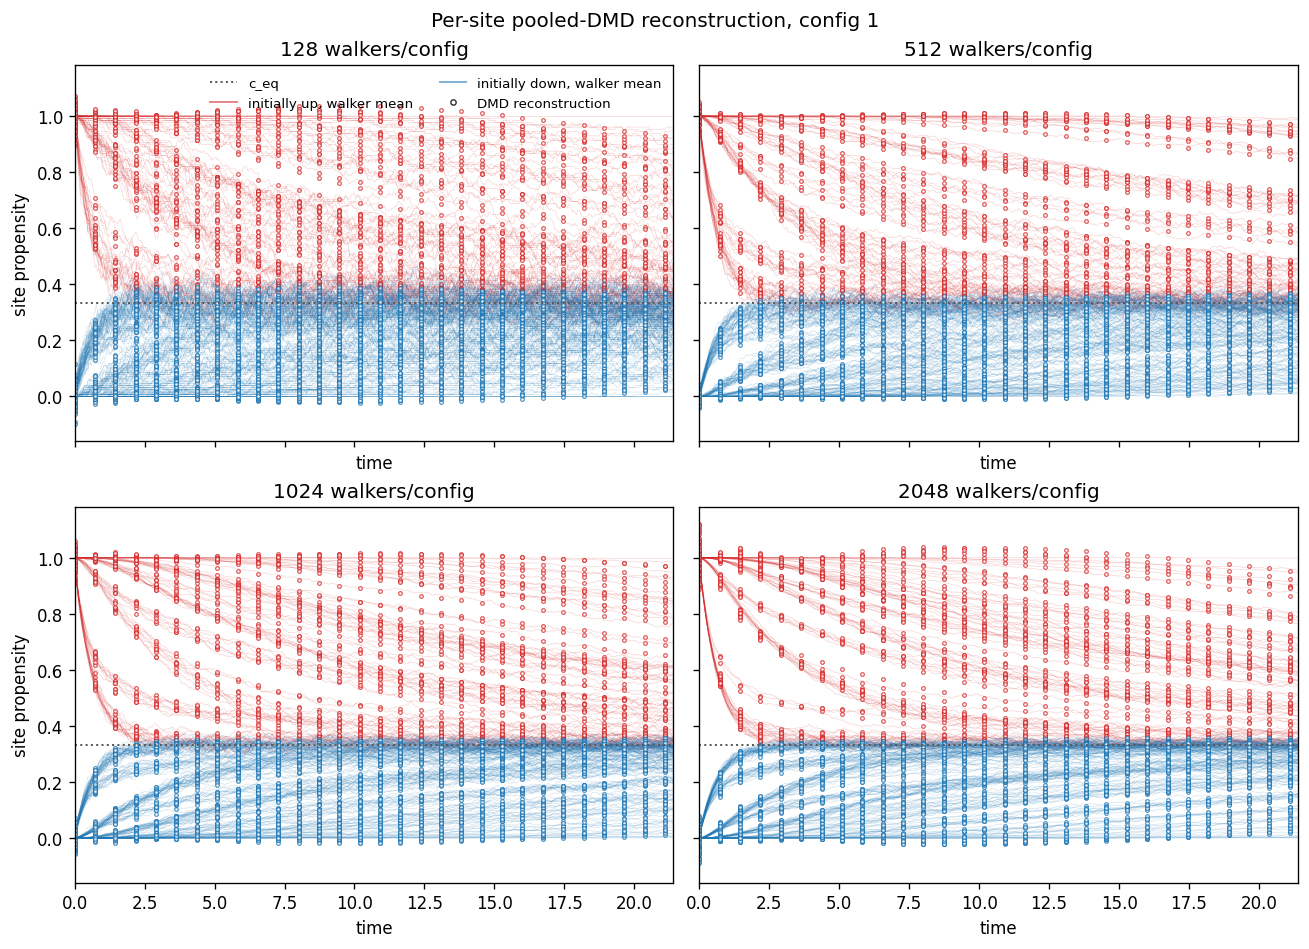

In [33]:
plot_config = 0
marker_stride = max(1, len(times) // 28)
fig, axes_grid = plt.subplots(2, 2, figsize=(10.8, 7.8), sharex=True, sharey=True, constrained_layout=True)
axes = axes_grid.ravel()
for ax in axes[len(walker_counts):]:
    ax.set_visible(False)

for ax, n_walkers in zip(axes, walker_counts):
    res = results[n_walkers]
    state_plot = res['state_inits'][plot_config]
    up_mask = state_plot == 1
    dn_mask = state_plot == 0

    mean_traj_plot = res['mean_trajs'][plot_config]
    mean_hat_plot = res['mean_hats'][plot_config]

    for idx in np.where(up_mask)[0]:
        ax.plot(times, mean_traj_plot[:, idx], color='tab:red', lw=0.45, alpha=0.18)
        ax.plot(times, mean_hat_plot[:, idx], color='tab:red', marker='o', ls='None', ms=2.2,
                mfc='white', mec='tab:red', mew=0.75, alpha=0.75, markevery=marker_stride)
    for idx in np.where(dn_mask)[0]:
        ax.plot(times, mean_traj_plot[:, idx], color='tab:blue', lw=0.45, alpha=0.18)
        ax.plot(times, mean_hat_plot[:, idx], color='tab:blue', marker='o', ls='None', ms=2.2,
                mfc='white', mec='tab:blue', mew=0.75, alpha=0.75, markevery=marker_stride)

    ax.axhline(c_eq, color='0.35', ls=':', lw=1.2, label='c_eq')
    ax.set_title(f'{n_walkers} walkers/config')
    ax.set_xlabel('time')
    ax.margins(x=0)

# Proxy artists keep the legend readable without labeling every site.
axes[0].plot([], [], color='tab:red', lw=1.2, alpha=0.55, label='initially up, walker mean')
axes[0].plot([], [], color='tab:blue', lw=1.2, alpha=0.55, label='initially down, walker mean')
axes[0].plot([], [], color='0.15', marker='o', ls='None', ms=3.2,
             mfc='white', mec='0.15', mew=0.8, label='DMD reconstruction')
axes[0].set_ylabel('site propensity')
axes[2].set_ylabel('site propensity')
axes[0].legend(frameon=False, ncol=2, fontsize=8)
fig.suptitle(f'Per-site pooled-DMD reconstruction, config {plot_config + 1}')


walkers= 128: pseudospectrum grid computed in 16.4s
walkers= 512: pseudospectrum grid computed in 17.9s
walkers=1024: pseudospectrum grid computed in 1.8s
walkers=2048: pseudospectrum grid computed in 1.1s


Text(0.5, 0.98, 'single-site pooled DMD spectra by walker count')

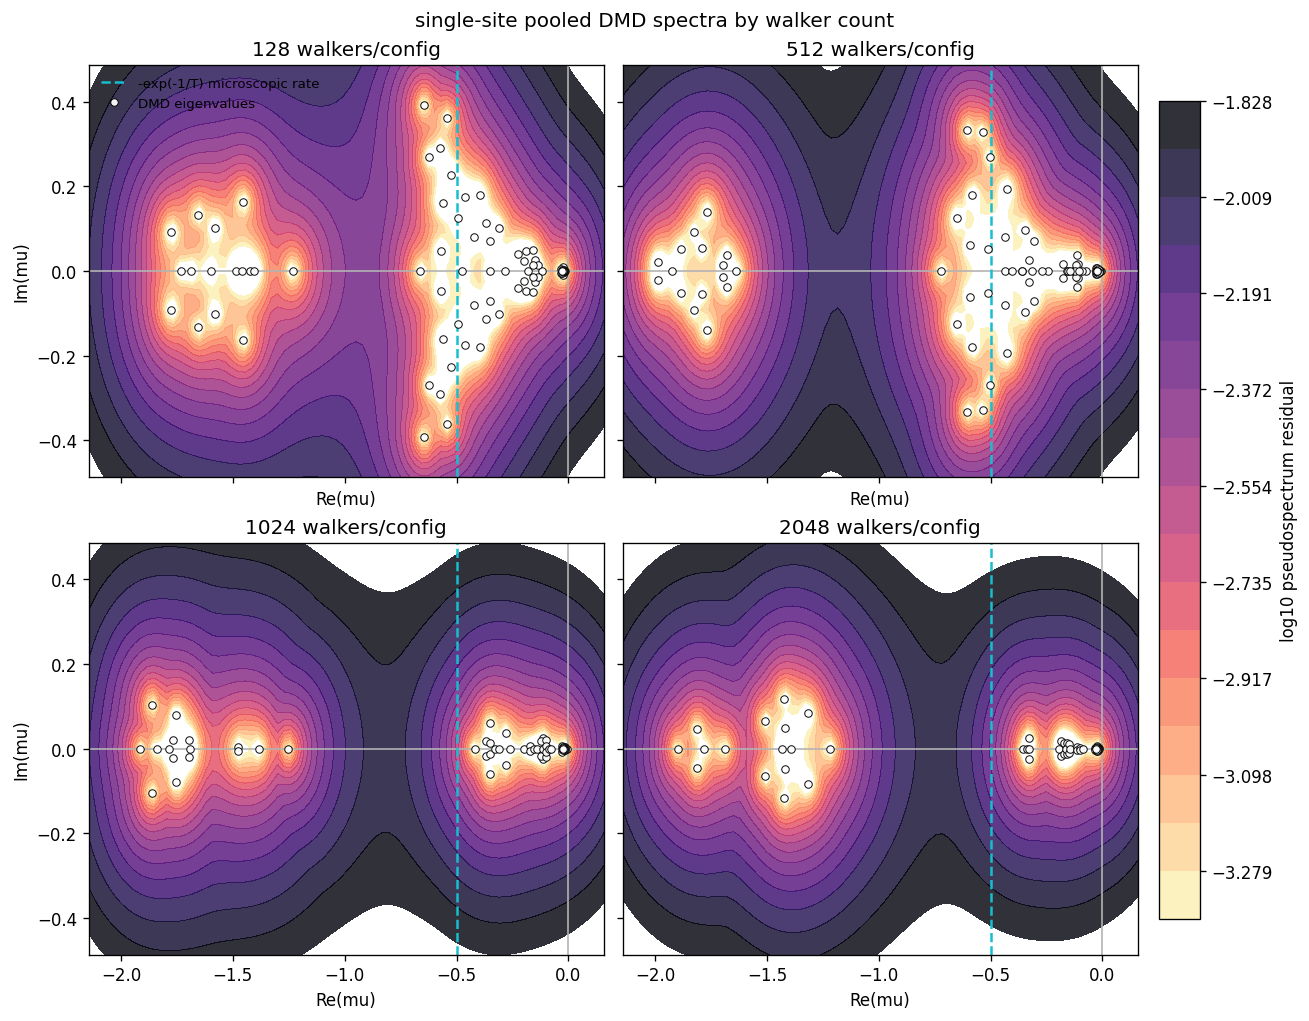

In [34]:
def dmd_pseudospectrum_mu(fit, dt, n_real=80, n_imag=60, real_grid=None, imag_grid=None):
    """Finite-dimensional DMD pseudospectrum in the continuous-time mu plane."""
    A = fit['A_tilde']
    if real_grid is None or imag_grid is None:
        mu = fit['mu']
        real = np.real(mu[np.isfinite(mu)])
        imag = np.imag(mu[np.isfinite(mu)])
        re_span = max(real.max() - real.min(), 1e-6)
        im_span = max(imag.max() - imag.min(), 1e-6)
        real_grid = np.linspace(real.min() - 0.08 * re_span,
                                max(0.0, real.max()) + 0.08 * re_span,
                                n_real)
        imag_grid = np.linspace(imag.min() - 0.12 * im_span,
                                imag.max() + 0.12 * im_span,
                                n_imag)

    eye = np.eye(A.shape[0], dtype=complex)
    sigma_min = np.empty((len(imag_grid), len(real_grid)), dtype=float)
    for j, im in enumerate(imag_grid):
        for i, re in enumerate(real_grid):
            z = np.exp((re + 1j * im) * dt)
            sigma_min[j, i] = np.linalg.svd(z * eye - A, compute_uv=False)[-1]

    return real_grid, imag_grid, np.log10(np.maximum(sigma_min, 1e-16))


plot_pseudospectrum = True

all_mu = np.concatenate([res['fit']['mu'] for res in results.values()])
finite_mu = all_mu[np.isfinite(all_mu)]
real_vals = np.real(finite_mu)
imag_vals = np.imag(finite_mu)

re_span = max(real_vals.max() - real_vals.min(), 1e-6)
im_span = max(imag_vals.max() - imag_vals.min(), 1e-6)
real_grid = np.linspace(real_vals.min() - 0.08 * re_span,
                        max(0.0, real_vals.max()) + 0.08 * re_span,
                        80)
imag_grid = np.linspace(imag_vals.min() - 0.12 * im_span,
                        imag_vals.max() + 0.12 * im_span,
                        60)

if plot_pseudospectrum:
    for n_walkers, res in results.items():
        t0 = time.time()
        re_grid, im_grid, log_sigma_min = dmd_pseudospectrum_mu(
            res['fit'], dt_record, real_grid=real_grid, imag_grid=imag_grid
        )
        res['pseudospectrum'] = {
            're_grid': re_grid,
            'im_grid': im_grid,
            'log_sigma_min': log_sigma_min,
        }
        print(f'walkers={n_walkers:4d}: pseudospectrum grid computed in {time.time() - t0:.1f}s')

fig, axes_grid = plt.subplots(2, 2, figsize=(10.8, 8.4), sharex=True, sharey=True, constrained_layout=True)
axes = axes_grid.ravel()
for ax in axes[len(walker_counts):]:
    ax.set_visible(False)

if plot_pseudospectrum:
    all_logs = np.concatenate([
        res['pseudospectrum']['log_sigma_min'].ravel()
        for res in results.values()
    ])
    levels = np.linspace(np.nanpercentile(all_logs, 5), np.nanpercentile(all_logs, 95), 18)
else:
    levels = None

cf = None
for ax, n_walkers in zip(axes, walker_counts):
    res = results[n_walkers]
    mu = res['fit']['mu']

    if plot_pseudospectrum:
        ps = res['pseudospectrum']
        cf = ax.contourf(ps['re_grid'], ps['im_grid'], ps['log_sigma_min'],
                         levels=levels, cmap='magma_r', alpha=0.82)

    ax.axvline(0, color='0.7', lw=1)
    ax.axhline(0, color='0.7', lw=1)
    ax.axvline(mu_micro, color='tab:cyan', ls='--', lw=1.5,
               label='-exp(-1/T) microscopic rate')
    ax.plot(np.real(mu), np.imag(mu), 'o', ms=4.5, color='white', mec='black', mew=0.6,
            alpha=0.95, label='DMD eigenvalues')
    ax.set_title(f'{n_walkers} walkers/config')
    ax.set_xlabel('Re(mu)')
    ax.set_xlim(real_grid[0], real_grid[-1])
    ax.set_ylim(imag_grid[0], imag_grid[-1])

axes[0].set_ylabel('Im(mu)')
axes[2].set_ylabel('Im(mu)')
axes[0].legend(frameon=False, loc='best', fontsize=8)
if cf is not None:
    cbar = fig.colorbar(cf, ax=axes_grid, location='right', shrink=0.92, pad=0.02)
    cbar.set_label('log10 pseudospectrum residual')
fig.suptitle('single-site pooled DMD spectra by walker count')


## Next extension

Once this pooled single-site walker-count comparison behaves sensibly, the next step is to replace `single_site_dictionary` with the downward-closed local cluster dictionary from `AGENTS.md`: evaluate products on each walker trajectory first, average those products over walkers, then apply the exact equilibrium centering/scaling for each cluster order.
